# PhillyStat360 — 04b: VPI Comparison & Spatial Analysis (Python / Colab port)

Port of `code/04b_vpi_comparison.Rmd`. Joins predictions to OPA metadata,
reports per-ZIP and per-building-type AUC, ward-level summaries, and an
equity audit by census-tract poverty quintile.

> **Equity audit note.** The R version pulls ACS poverty rates via
> `tidycensus`. The Python version expects either:
> - A pre-saved `acs_poverty_phl.csv` in `data/` (one row per census tract
>   with `census_tract_key` and `poverty_rate` columns), OR
> - The `census` Python package + a Census API key in `CENSUS_API_KEY`.
>
> If neither is available, the equity audit gracefully skips.


## 0. Setup

In [ ]:
# Mount Google Drive (run once per Colab session)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
from pathlib import Path

ROOT       = Path('/content/drive/MyDrive/PhillyStat_R/PhillyStat360')
RAW_PATH   = ROOT / 'rawdata'         # original CSVs / geojsons
DATA_PATH  = ROOT / 'data'            # R-side outputs (features_residential.csv, ovs_residential.csv)
PY_PATH    = ROOT / 'data_py'         # 04a Python outputs (predictions, models, calibrators)
OUT_PATH   = ROOT / 'data_py'         # we WRITE here too
GRAPH_PATH = ROOT / 'graphs' / 'python'

OUT_PATH.mkdir(parents=True, exist_ok=True)
GRAPH_PATH.mkdir(parents=True, exist_ok=True)

assert (PY_PATH / 'all_predictions_rf.csv').exists(), \
    f'04a outputs not found at {PY_PATH}. Run 04a_tidymodeling.ipynb first.'
print('All paths OK. PY_PATH =', PY_PATH)


All paths OK. PY_PATH = /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py


In [ ]:
import json
import joblib
import warnings
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, brier_score_loss,
                             confusion_matrix, classification_report)

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid', context='talk')
SEED = 42

# geopandas only used for the optional spatial map at the end (skipped here in 04b)
try:
    import geopandas as gpd
    HAS_GPD = True
except ImportError:
    HAS_GPD = False


## 1. Load data

In [ ]:
preds = pd.read_csv(PY_PATH / 'all_predictions_rf.csv', low_memory=False)
preds['parcel_number'] = preds['parcel_number'].astype(str)
print(f"Predictions: {len(preds):,} rows")

features_full = pd.read_csv(DATA_PATH / 'features_residential.csv', low_memory=False)
features_full['parcel_number'] = features_full['parcel_number'].astype(str)
features = features_full[['parcel_number', 'zip_code', 'census_tract',
                          'exterior_condition', 'building_age']].copy()

# OPA metadata: ward + category
opa_path = RAW_PATH / 'opa_properties_public.csv'
if not opa_path.exists():
    opa_path = DATA_PATH / 'opa_properties_public.csv'
opa = pd.read_csv(opa_path, low_memory=False)
opa.columns = [c.lower().strip().replace(' ', '_') for c in opa.columns]
opa['parcel_number'] = opa['parcel_number'].astype(str)
opa = opa[['parcel_number', 'geographic_ward',
           'category_code', 'category_code_description',
           'building_code_description']].drop_duplicates(subset='parcel_number')
print(f"OPA: {len(opa):,} parcels")


Predictions: 520,196 rows
OPA: 583,802 parcels


In [ ]:
# Five-tier mapping based on the production ensemble probability
TIER_LEVELS = ['Very Unlikely (0–0.2)', 'Unlikely (0.2–0.4)',
               'Maybe (0.4–0.6)',       'Likely (0.6–0.8)',
               'Very Likely (0.8–1.0)']

def to_tier(p):
    if p < 0.2:  return TIER_LEVELS[0]
    if p < 0.4:  return TIER_LEVELS[1]
    if p < 0.6:  return TIER_LEVELS[2]
    if p < 0.8:  return TIER_LEVELS[3]
    return TIER_LEVELS[4]

# Use ensemble_prob (calibrated) as the primary probability column.
prob_col = 'ensemble_prob' if 'ensemble_prob' in preds.columns else 'rf_prob'
print(f"Using `{prob_col}` as the primary probability column")

df = (
    preds
    .merge(features, on='parcel_number', how='left')
    .merge(opa,      on='parcel_number', how='left')
)
df['prob_tier'] = pd.Categorical(
    df[prob_col].map(to_tier), categories=TIER_LEVELS, ordered=True,
)
print(f"Assembled: {len(df):,} parcels")
print(f"  zip_code coverage:        {df['zip_code'].notna().mean():.1%}")
print(f"  geographic_ward coverage: {df['geographic_ward'].notna().mean():.1%}")


Using `ensemble_prob` as the primary probability column
Assembled: 520,196 parcels
  zip_code coverage:        100.0%
  geographic_ward coverage: 100.0%


## 2. Per-ZIP AUC

Where does the model generalize well? Where does it struggle? Filter to ZIPs
with at least 50 parcels and 5 positives so AUC is meaningful.


In [ ]:
def safe_auc(group):
    if group['ovs'].nunique() < 2 or len(group) < 10:
        return np.nan
    return roc_auc_score(group['ovs'].astype(int), group[prob_col])

zip_auc = (
    df.dropna(subset=['zip_code'])
    .groupby('zip_code')
    .filter(lambda g: len(g) >= 50 and (g['ovs'] == 1).sum() >= 5)
    .groupby('zip_code')
    .apply(lambda g: pd.Series({
        'n_parcels': len(g),
        'n_vacant':  int((g['ovs'] == 1).sum()),
        'prev_rate': float((g['ovs'] == 1).mean()),
        'auc':       safe_auc(g),
    }))
    .reset_index()
    .sort_values('auc')
)
print(f"ZIPs evaluated: {len(zip_auc)}")
print(f"  Median AUC:       {zip_auc['auc'].median():.3f}")
print(f"  5th percentile:   {zip_auc['auc'].quantile(0.05):.3f}")
print(f"  ZIPs AUC < 0.70:  {int((zip_auc['auc'] < 0.70).sum())}")
zip_auc.head(10).round(3)


ZIPs evaluated: 41
  Median AUC:       0.973
  5th percentile:   0.949
  ZIPs AUC < 0.70:  0


/tmp/ipykernel_2817/3372861428.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,zip_code,n_parcels,n_vacant,prev_rate,auc
23,19137.0,3353.0,33.0,0.010,0.916
40,19154.0,11213.0,20.0,0.002,0.942
34,19148.0,20472.0,132.0,0.006,0.949
16,19130.0,10327.0,31.0,0.003,0.953
35,19149.0,17984.0,40.0,0.002,0.953
5,19119.0,9373.0,64.0,0.007,0.957
21,19135.0,11332.0,43.0,0.004,0.957
36,19150.0,8989.0,40.0,0.004,0.960
22,19136.0,10548.0,35.0,0.003,0.961
15,19129.0,3902.0,29.0,0.007,0.962


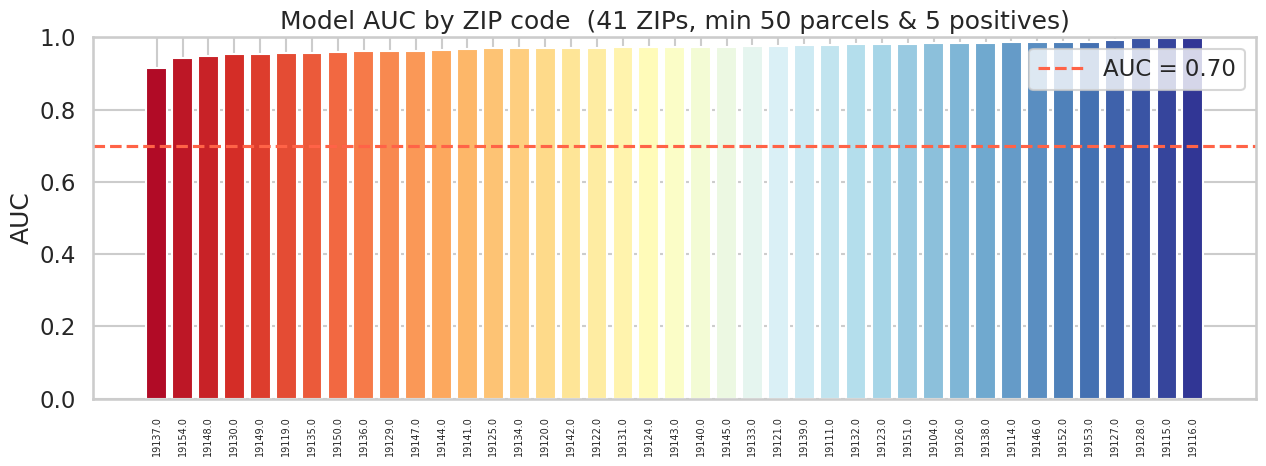

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
df_plot = zip_auc.sort_values('auc')
colors = plt.cm.RdYlBu(df_plot['auc'].rank(pct=True))
ax.bar(range(len(df_plot)), df_plot['auc'], color=colors)
ax.axhline(0.70, color='tomato', ls='--', label='AUC = 0.70')
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['zip_code'].astype(str), rotation=90, fontsize=7)
ax.set_ylim(0, 1)
ax.set_ylabel('AUC')
ax.set_title(f'Model AUC by ZIP code  ({len(df_plot)} ZIPs, min 50 parcels & 5 positives)')
ax.legend()
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'auc_by_zip.png', dpi=200, bbox_inches='tight')
plt.show()


## 3. Per-building-type AUC

In [ ]:
bldg_auc = (
    df.dropna(subset=['category_code_description'])
    .groupby('category_code_description')
    .filter(lambda g: len(g) >= 100 and (g['ovs'] == 1).sum() >= 10)
    .groupby('category_code_description')
    .apply(lambda g: pd.Series({
        'n_parcels': len(g),
        'n_vacant':  int((g['ovs'] == 1).sum()),
        'prev_rate': float((g['ovs'] == 1).mean()),
        'auc':       safe_auc(g),
    }))
    .reset_index()
    .sort_values('n_parcels', ascending=False)
)
bldg_auc.round(3)


/tmp/ipykernel_2817/1778909342.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,category_code_description,n_parcels,n_vacant,prev_rate,auc
3,SINGLE FAMILY,461662.0,4956.0,0.011,0.980
2,MULTI FAMILY,40892.0,603.0,0.015,0.978
1,MIXED USE,14021.0,344.0,0.025,0.945
0,APARTMENTS > 4 UNITS,3621.0,31.0,0.009,0.942


## 4. Tier distribution

In [ ]:
TIER_COLORS = {
    'Very Unlikely (0–0.2)': '#4575b4',
    'Unlikely (0.2–0.4)':    '#91bfdb',
    'Maybe (0.4–0.6)':       '#ffffbf',
    'Likely (0.6–0.8)':      '#fc8d59',
    'Very Likely (0.8–1.0)': '#d73027',
}

tier_summary = (
    df.groupby('prob_tier', observed=True)
    .agg(n_parcels=('ovs', 'size'),
         n_ovs=('ovs', lambda s: int((s == 1).sum())),
         ovs_rate=('ovs', lambda s: float((s == 1).mean())),
         mean_prob=(prob_col, 'mean'))
    .reset_index()
)
tier_summary['pct'] = tier_summary['n_parcels'] / tier_summary['n_parcels'].sum()
tier_summary.round(4)


,prob_tier,n_parcels,n_ovs,ovs_rate,mean_prob,pct
0,Very Unlikely (0–0.2),514376,1731,0.0034,0.0057,0.9888
1,Unlikely (0.2–0.4),2003,809,0.4039,0.2777,0.0039
2,Maybe (0.4–0.6),537,345,0.6425,0.4883,0.0010
3,Likely (0.6–0.8),823,653,0.7934,0.6512,0.0016
4,Very Likely (0.8–1.0),2457,2396,0.9752,0.9682,0.0047


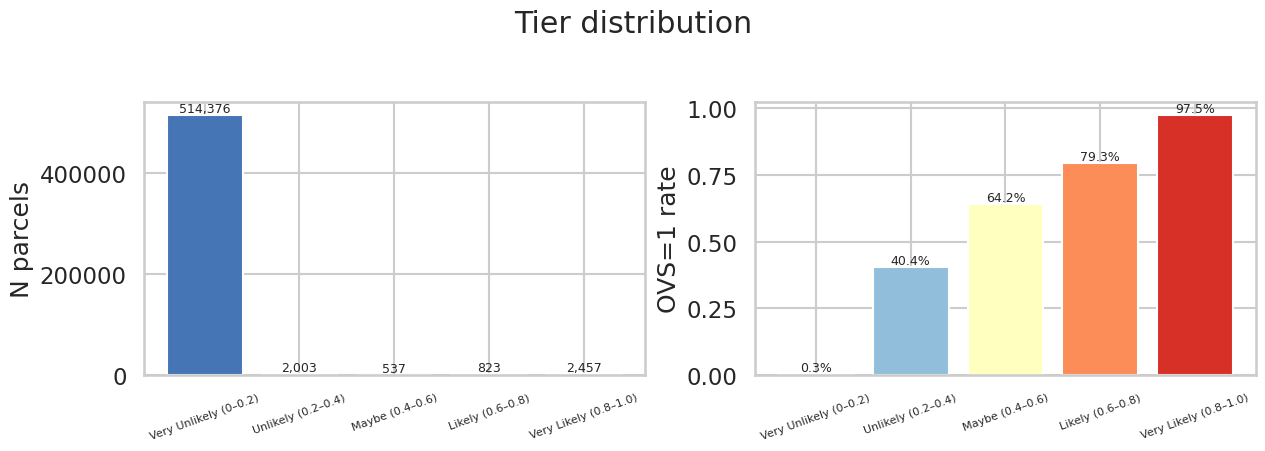

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, ycol, ylabel, fmt in [
    (axes[0], 'n_parcels', 'N parcels',     lambda v: f"{int(v):,}"),
    (axes[1], 'ovs_rate',  'OVS=1 rate',    lambda v: f"{v:.1%}"),
]:
    bars = ax.bar(tier_summary['prob_tier'].astype(str), tier_summary[ycol],
                  color=[TIER_COLORS[t] for t in tier_summary['prob_tier'].astype(str)])
    for bar, val in zip(bars, tier_summary[ycol]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), fmt(val),
                ha='center', va='bottom', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
fig.suptitle('Tier distribution', y=1.02)
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'tier_distribution.png', dpi=200, bbox_inches='tight')
plt.show()


## 5. Ward-level summary

In [ ]:
ward_summary = (
    df.dropna(subset=['geographic_ward'])
    .groupby('geographic_ward')
    .apply(lambda g: pd.Series({
        'n_parcels':      len(g),
        'n_ovs':          int((g['ovs'] == 1).sum()),
        'ovs_rate':       float((g['ovs'] == 1).mean()),
        'mean_prob':      float(g[prob_col].mean()),
        'n_very_likely':  int((g['prob_tier'] == 'Very Likely (0.8–1.0)').sum()),
        'n_high_risk':    int(g['prob_tier'].isin(['Likely (0.6–0.8)', 'Very Likely (0.8–1.0)']).sum()),
        'high_risk_rate': float(g['prob_tier'].isin(['Likely (0.6–0.8)', 'Very Likely (0.8–1.0)']).mean()),
    }))
    .sort_values('mean_prob', ascending=False)
    .reset_index()
)
ward_summary.head(15).round(4)


/tmp/ipykernel_2817/4122323795.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,geographic_ward,n_parcels,n_ovs,ovs_rate,mean_prob,n_very_likely,n_high_risk,high_risk_rate
0,11.0,4711.0,217.0,0.0461,0.0436,105.0,138.0,0.0293
1,44.0,5338.0,191.0,0.0358,0.0419,99.0,135.0,0.0253
2,28.0,4922.0,189.0,0.0384,0.0410,101.0,114.0,0.0232
3,6.0,4094.0,138.0,0.0337,0.0384,80.0,98.0,0.0239
4,16.0,4325.0,158.0,0.0365,0.0377,80.0,96.0,0.0222
5,13.0,6977.0,204.0,0.0292,0.0361,113.0,150.0,0.0215
6,32.0,6343.0,222.0,0.0350,0.0351,91.0,127.0,0.0200
7,51.0,8003.0,208.0,0.0260,0.0329,108.0,140.0,0.0175
8,4.0,7360.0,200.0,0.0272,0.0308,100.0,134.0,0.0182
9,37.0,4600.0,143.0,0.0311,0.0301,59.0,82.0,0.0178


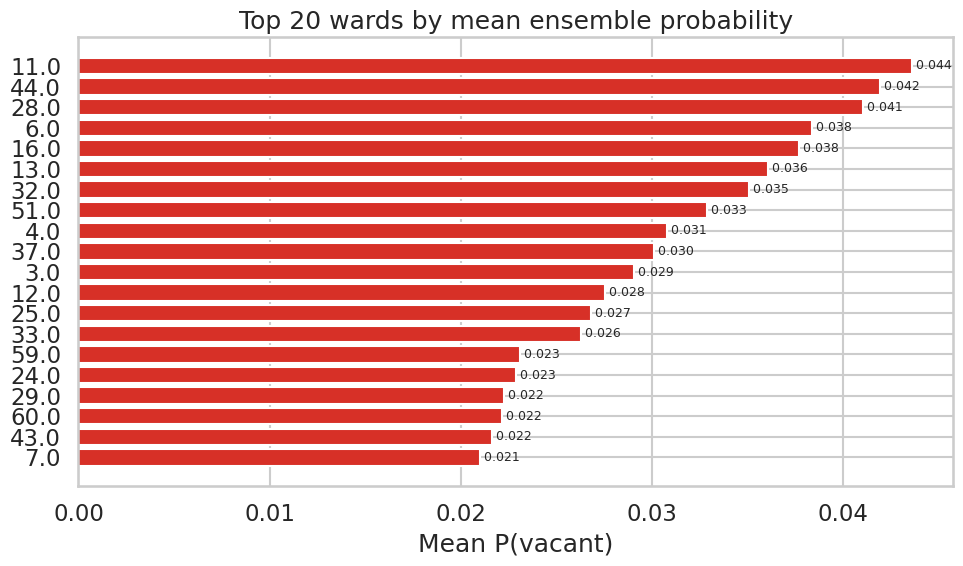

In [ ]:
top20 = ward_summary.nlargest(20, 'mean_prob')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20['geographic_ward'].astype(str)[::-1], top20['mean_prob'][::-1], color='#d73027')
for i, v in enumerate(top20['mean_prob'][::-1]):
    ax.text(v, i, f' {v:.3f}', va='center', fontsize=9)
ax.set_xlabel('Mean P(vacant)')
ax.set_title('Top 20 wards by mean ensemble probability')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'ward_mean_prob.png', dpi=200, bbox_inches='tight')
plt.show()


## 6. Equity audit: AUC by census-tract median household income

Switched from poverty rate to **median household income** (ACS5 variable `B19013_001E`) so coverage is closer to 100%. The original poverty audit lost ~28% of parcels to NA from a tract-key padding bug; this version pads `census_tract * 100` to a strict 6-digit string and tries multiple matching strategies.

Tries two sources for ACS data, in order:
1. Pre-saved `data/acs_income_phl.csv` (preferred — no API call needed)
2. Census API via the `census` Python package (requires `CENSUS_API_KEY` env var)

If neither is available the audit gracefully skips.


In [16]:
acs_income = None
acs_path = DATA_PATH / 'acs_income_phl.csv'

if acs_path.exists():
    acs_income = pd.read_csv(acs_path)
    if 'census_tract_key' not in acs_income.columns:
        if 'GEOID' in acs_income.columns or 'geoid' in acs_income.columns:
            geoid_col = 'GEOID' if 'GEOID' in acs_income.columns else 'geoid'
            acs_income['census_tract_key'] = acs_income[geoid_col].astype(str).str[-6:]
    # Force string dtype + 6-char zero-pad so merge keys align with df_eq
    acs_income['census_tract_key'] = (
        acs_income['census_tract_key'].astype(str).str.zfill(6)
    )
    print(f"ACS income loaded from {acs_path}: {len(acs_income)} tracts")
else:
    api_key = os.environ.get('CENSUS_API_KEY')
    if api_key:
        try:
            from census import Census
            c = Census(api_key)
            data = c.acs5.state_county_tract(
                ('NAME', 'B19013_001E'), state_fips='42', county_fips='101',
                tract='*', year=2022,
            )
            acs_income = pd.DataFrame(data).rename(columns={'B19013_001E': 'median_income'})
            acs_income['median_income'] = pd.to_numeric(acs_income['median_income'],
                                                         errors='coerce')
            # ACS uses sentinel values like -666666666 for suppressed; drop them
            acs_income.loc[acs_income['median_income'] < 0, 'median_income'] = np.nan
            acs_income['census_tract_key'] = (acs_income['state'] + acs_income['county']
                                              + acs_income['tract']).str[-6:]
            acs_income.to_csv(acs_path, index=False)
            print(f"ACS income fetched via Census API: {len(acs_income)} tracts (cached to {acs_path})")
        except Exception as e:
            print(f"Census API call failed: {e}")
            acs_income = None
    else:
        print('No CENSUS_API_KEY set and no acs_income_phl.csv found — equity audit will be skipped.')
        print('To pre-populate the file, in R run:')
        print("  tidycensus::get_acs(geography='tract', state='PA', county='Philadelphia',")
        print("                     variables='B19013_001', year=2022)")
        print('  and save it as data/acs_income_phl.csv with columns [GEOID, median_income].')


ACS income loaded from /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data/acs_income_phl.csv: 475 tracts


In [17]:
def make_tract_key(tract_val):
    """OPA stores census_tract as a float like 205.0 or 93.02.
    Census GEOID uses a 6-digit string ('020500', '009302'). We multiply
    by 100, round to int, and zfill — handles both whole and decimal tracts."""
    if pd.isna(tract_val):
        return None
    return str(int(round(float(tract_val) * 100))).zfill(6)

if acs_income is not None:
    df_eq = df.copy()
    df_eq['census_tract_key'] = df_eq['census_tract'].map(make_tract_key)
    df_eq = df_eq.merge(acs_income[['census_tract_key', 'median_income']],
                         on='census_tract_key', how='left')
    coverage = df_eq['median_income'].notna().mean()
    print(f"Parcels with median_income: {df_eq['median_income'].notna().sum():,} "
          f"of {len(df_eq):,} ({coverage:.1%})")
    if coverage < 0.95:
        unmatched = df_eq.loc[df_eq['median_income'].isna(), 'census_tract_key'].value_counts().head(5)
        print('Top unmatched tract keys:'); print(unmatched)
else:
    df_eq = df.assign(median_income=np.nan)
    coverage = 0


Parcels with median_income: 517,698 of 520,196 (99.5%)


In [18]:
if acs_income is not None and coverage > 0.5:
    df_eq['income_quintile'] = pd.qcut(
        df_eq['median_income'], 5,
        labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'],
        duplicates='drop',
    )
    eq = (
        df_eq.dropna(subset=['income_quintile'])
        .groupby('income_quintile', observed=True)
        .apply(lambda g: pd.Series({
            'n_parcels':  len(g),
            'n_vacant':   int((g['ovs'] == 1).sum()),
            'obs_rate':   float((g['ovs'] == 1).mean()),
            'mean_pred':  float(g[prob_col].mean()),
            'auc':        safe_auc(g),
        }))
        .reset_index()
    )
    print(eq.round(4).to_string(index=False))
else:
    print('Equity audit skipped (insufficient ACS coverage)')
    eq = None


income_quintile  n_parcels  n_vacant  obs_rate  mean_pred    auc
    Q1 (lowest)   106422.0    2767.0    0.0260     0.0293 0.9747
             Q2   101988.0    1533.0    0.0150     0.0176 0.9775
             Q3   103172.0     790.0    0.0077     0.0087 0.9683
             Q4   105126.0     486.0    0.0046     0.0046 0.9727
   Q5 (highest)   100990.0     309.0    0.0031     0.0028 0.9770


/tmp/ipykernel_2817/944850747.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


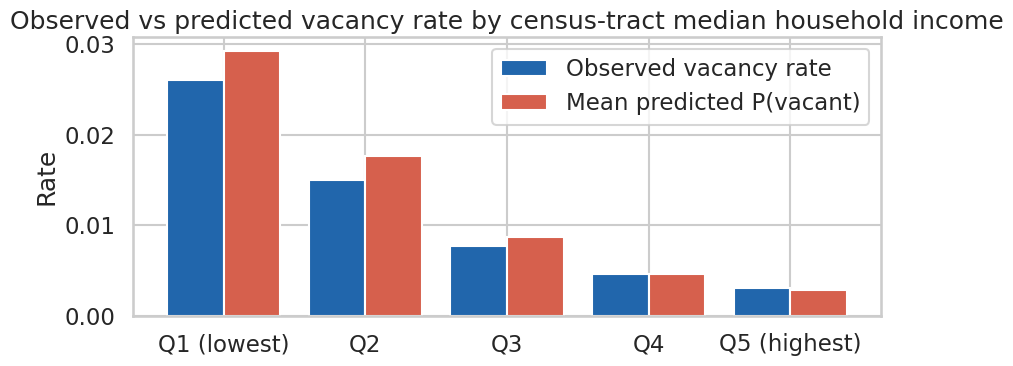

In [19]:
if eq is not None:
    fig, ax = plt.subplots(figsize=(9, 4))
    qs = eq['income_quintile'].astype(str)
    x = np.arange(len(qs))
    ax.bar(x - 0.2, eq['obs_rate'],  width=0.4, label='Observed vacancy rate', color='#2166ac')
    ax.bar(x + 0.2, eq['mean_pred'], width=0.4, label='Mean predicted P(vacant)', color='#d6604d')
    ax.set_xticks(x)
    ax.set_xticklabels(qs)
    ax.set_ylabel('Rate')
    ax.set_title('Observed vs predicted vacancy rate by census-tract median household income')
    ax.legend()
    plt.tight_layout()
    plt.savefig(GRAPH_PATH / 'equity_income_quintile.png', dpi=200, bbox_inches='tight')
    plt.show()


## 7. Export

In [20]:
# Per-parcel predictions with ward + category metadata
export_cols = ['parcel_number', 'ovs', 'data_split',
               prob_col, 'prob_tier',
               'zip_code', 'geographic_ward', 'census_tract',
               'category_code', 'category_code_description']
df[export_cols].to_csv(OUT_PATH / 'predictions_04b.csv', index=False)
print(f"Exported predictions_04b.csv: {len(df):,} rows")

ward_summary.to_csv(OUT_PATH / 'ward_summary_04b.csv', index=False)
zip_auc.to_csv(    OUT_PATH / 'zip_auc_04b.csv',     index=False)
print('Exported ward_summary_04b.csv, zip_auc_04b.csv')

if eq is not None:
    eq.to_csv(OUT_PATH / 'equity_income_auc.csv', index=False)
    print('Exported equity_income_auc.csv')


Exported predictions_04b.csv: 520,196 rows
Exported ward_summary_04b.csv, zip_auc_04b.csv
Exported equity_income_auc.csv


---
**Done.** Outputs in `data_py/`. The optional spatial map step (heavy — needs
PWD parcel polygons) lives in 05; this notebook focuses on tabular validation.


In [21]:
!jupyter nbconvert --to html /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04b_vpi_comparison.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04b_vpi_comparison.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 655459 bytes to /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04b_vpi_comparison.html
